# Notebook 05: Lake Mead Wildfire Clustering -- Minimum Viable Test

**Obstacle-Aware Clustering for Geographic Data**

The Lake Tahoe analysis in Notebook 03 showed that the boundary parameter $s$ doesn't substantially help geometric clustering on that dataset. Tahoe is roughly round and ~22 miles across at its widest; fires on opposite shores are already far apart in straight-line distance, so the lake doesn't create a clustering ambiguity that $s$ needs to resolve.

Lake Mead has a very different geometry: long, narrow, with multiple arms (Overton Arm, Boulder Basin, Black Canyon). Fires near opposite banks can be close in latitude/longitude but separated by water. This is the regime where obstacle-aware clustering should clearly help.

This notebook is a focused test: build the boundary spline, pull the fires, and compare standard $k$-means against obstacle-aware $k$-means at equal weights and at an optimized $\beta$ -- all using only spatial features (no attributes). If $s$ produces a visibly different and more sensible clustering on Lake Mead, we proceed to a fuller analysis. If not, we reconsider the case study before investing further.

### What this notebook does NOT do

To stay focused on the core question, this notebook skips:
- Attribute-based clustering (cause, fire size) -- those come back later if the spatial test succeeds
- Near-shore vs. basin-wide comparison -- a follow-up question once we know $s$ helps at all
- Detailed cluster profiling, dashboards, or writeup figures

The attributes are still extracted and saved with the cleaned data, in case we want to look at $\sigma_a$ as a side note.

## 1. Setup

In [1]:
import os
# Prevent sklearn/KMeans from spawning parallel threads on Windows
# (also suppresses a harmless OpenMP warning)
os.environ['OMP_NUM_THREADS'] = '1'

# Suppress unecessary warnings
import warnings
from scipy.integrate import IntegrationWarning
warnings.filterwarnings('ignore', category=IntegrationWarning)
warnings.filterwarnings('ignore', message='.*Intel OpenMP.*')

# Standard packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sqlite3
import pickle

# For querying the NHD ArcGIS REST endpoint
import requests

# For polygon clipping during boundary cleanup
from shapely.geometry import Polygon as ShapelyPolygon, Point

#For normalizing variables in feature matrix
from sklearn.preprocessing import MinMaxScaler

# sklearn baselines
from sklearn.cluster import KMeans

# Our custom package
from obstacle_clustering import SplineBoundary, ObstacleKMeans, attribute_separation
from obstacle_clustering.optimization import objective_function

# --- Plot style ---
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 13,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18,
})

# Cluster colors (consistent with the rest of the project)
CLUSTER_COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# --- Caching ---
cache_dir = Path('../data/cached')
cache_dir.mkdir(parents=True, exist_ok=True)


def cached_or_run(cache_path, compute_fn, force_rerun=False):
    """Load from cache if it exists, otherwise run compute_fn and save."""
    cache_path = Path(cache_path)
    if cache_path.exists() and not force_rerun:
        print(f'Loading cached: {cache_path.name}')
        with open(cache_path, 'rb') as f:
            return pickle.load(f)
    print(f'Computing (will cache to {cache_path.name})...')
    result = compute_fn()
    with open(cache_path, 'wb') as f:
        pickle.dump(result, f)
    return result


# --- Helpers ---
def arc_length_span(s_values):
    """Calculate the arc-length span of a cluster on the loop [0, 1]."""
    if len(s_values) <= 1:
        return 0.0
    sorted_s = np.sort(s_values)
    gaps = np.diff(sorted_s)
    wrap_gap = (1.0 - sorted_s[-1]) + sorted_s[0]
    largest_gap = max(gaps.max(), wrap_gap)
    return 1.0 - largest_gap

## 2. Querying the USGS National Hydrography Dataset

Same pattern as Notebook 02: hit the public NHD Waterbody endpoint and pull Lake Mead's polygon. The NHD lists Lake Mead as a separate feature from the adjacent Lake Mohave downstream, so a simple name filter works.

Lake Mead is much larger and more complex than Tahoe -- it has multiple major arms, and the raw polygon will likely have an order of magnitude more vertices. We'll handle the cleanup in the next section.

In [2]:
# USGS NHD Waterbody - Large Scale layer (1:24,000)
# Lake Mead is a reservoir; the small-scale layer 10 doesn't include it
NHD_WATERBODY_URL = (
    "https://hydro.nationalmap.gov/arcgis/rest/services/nhd/MapServer/12/query"
)

# Build the query parameters
params = {
    'where': "GNIS_NAME = 'Lake Mead'",
    'outFields': 'GNIS_NAME,AREASQKM,ELEVATION,REACHCODE',
    'returnGeometry': 'true',
    'outSR': 4326,                          # WGS 84 (lat/lon)
    'f': 'json',
}

response = requests.get(NHD_WATERBODY_URL, params=params)
response.raise_for_status()
data = response.json()

n_features = len(data['features'])
print(f'Features returned: {n_features}')

for feat in data['features']:
    attrs = feat['attributes']
    print(f"  Name:       {attrs['GNIS_NAME']}")
    print(f"  Area:       {attrs['AREASQKM']:.1f} sq km")
    print(f"  Elevation:  {attrs.get('ELEVATION', 'n/a')}")
    print(f"  Reach Code: {attrs['REACHCODE']}")
    print()

Features returned: 5
  Name:       Lake Mead
  Area:       0.0 sq km
  Elevation:  None
  Reach Code: 01100006001704

  Name:       Lake Mead
  Area:       541.3 sq km
  Elevation:  1157
  Reach Code: 15010005009521

  Name:       Lake Mead
  Area:       0.1 sq km
  Elevation:  None
  Reach Code: 10090206001013

  Name:       Lake Mead
  Area:       0.7 sq km
  Elevation:  1157
  Reach Code: 15010014003280

  Name:       Lake Mead
  Area:       7.2 sq km
  Elevation:  1157
  Reach Code: 15010006010760



### Extracting Boundary Coordinates

The NHD response stores polygon geometry as nested rings: `feature -> geometry -> rings -> [[lon, lat], ...]`. If multiple features come back (different lake fragments or historical entries), we take the largest by area. If a single feature has multiple rings, we use the longest one as the exterior boundary.

In [3]:
# Pick the largest feature if there are multiple, then the longest ring inside it
if n_features > 1:
    feat = max(data['features'], key=lambda f: f['attributes']['AREASQKM'])
    print(f"Multiple features found -- using the largest "
          f"({feat['attributes']['AREASQKM']:.1f} sq km)")
else:
    feat = data['features'][0]

rings = feat['geometry']['rings']
print(f'Number of rings: {len(rings)}')
for i, ring in enumerate(rings):
    print(f'  Ring {i}: {len(ring)} vertices')

# Use the longest ring as the exterior boundary
exterior_ring = max(rings, key=len)
coords = np.array(exterior_ring)
lon = coords[:, 0]
lat = coords[:, 1]

print(f'\nExterior ring: {len(lon)} vertices')
print(f'Longitude range: [{lon.min():.4f}, {lon.max():.4f}]')
print(f'Latitude range:  [{lat.min():.4f}, {lat.max():.4f}]')

# Verify the ring is closed
is_closed = np.allclose(coords[0], coords[-1])
print(f'Ring is closed: {is_closed}')

Multiple features found -- using the largest (541.3 sq km)
Number of rings: 188
  Ring 0: 73155 vertices
  Ring 1: 32 vertices
  Ring 2: 15 vertices
  Ring 3: 30 vertices
  Ring 4: 18 vertices
  Ring 5: 129 vertices
  Ring 6: 19 vertices
  Ring 7: 12 vertices
  Ring 8: 17 vertices
  Ring 9: 22 vertices
  Ring 10: 10 vertices
  Ring 11: 7 vertices
  Ring 12: 10 vertices
  Ring 13: 10 vertices
  Ring 14: 22 vertices
  Ring 15: 13 vertices
  Ring 16: 24 vertices
  Ring 17: 148 vertices
  Ring 18: 14 vertices
  Ring 19: 14 vertices
  Ring 20: 9 vertices
  Ring 21: 9 vertices
  Ring 22: 20 vertices
  Ring 23: 43 vertices
  Ring 24: 11 vertices
  Ring 25: 9 vertices
  Ring 26: 18 vertices
  Ring 27: 28 vertices
  Ring 28: 40 vertices
  Ring 29: 254 vertices
  Ring 30: 7 vertices
  Ring 31: 27 vertices
  Ring 32: 159 vertices
  Ring 33: 175 vertices
  Ring 34: 188 vertices
  Ring 35: 9 vertices
  Ring 36: 31 vertices
  Ring 37: 49 vertices
  Ring 38: 32 vertices
  Ring 39: 18 vertices
  Ring 

### Visualizing the Raw Boundary

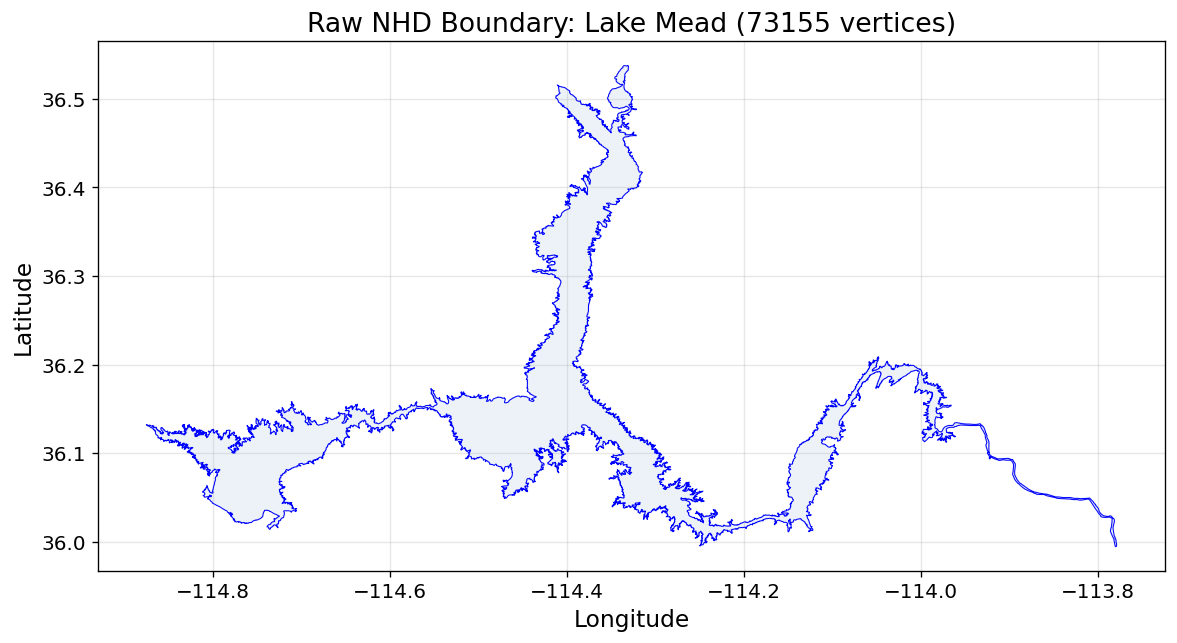

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(lon, lat, 'b-', linewidth=0.6)
ax.fill(lon, lat, alpha=0.1, color='steelblue')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Raw NHD Boundary: Lake Mead ({len(lon)} vertices)')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Cleaning the Boundary

Lake Mead's raw NHD polygon has far more vertices than the spline needs. We simplify with Shapely's tolerance-based simplification (Douglas-Peucker). The tolerance is in degrees; at this latitude, 0.001 degrees is roughly 90 m, which is plenty fine for a lake whose major arms stretch tens of kilometers.

A tolerance higher than what we used for Tahoe (0.0005) is appropriate because Lake Mead is so much bigger -- we don't need 100 m resolution on a 180 km waterbody. We're aiming for a few hundred vertices, which the cubic spline will handle smoothly.

Lake Mead doesn't have an analog of the Tahoe Keys (the small subset we manually clipped in Notebook 02), so no manual clipping needed here -- just simplification.

Vertices before simplification: 73155
Vertices after simplification:  405


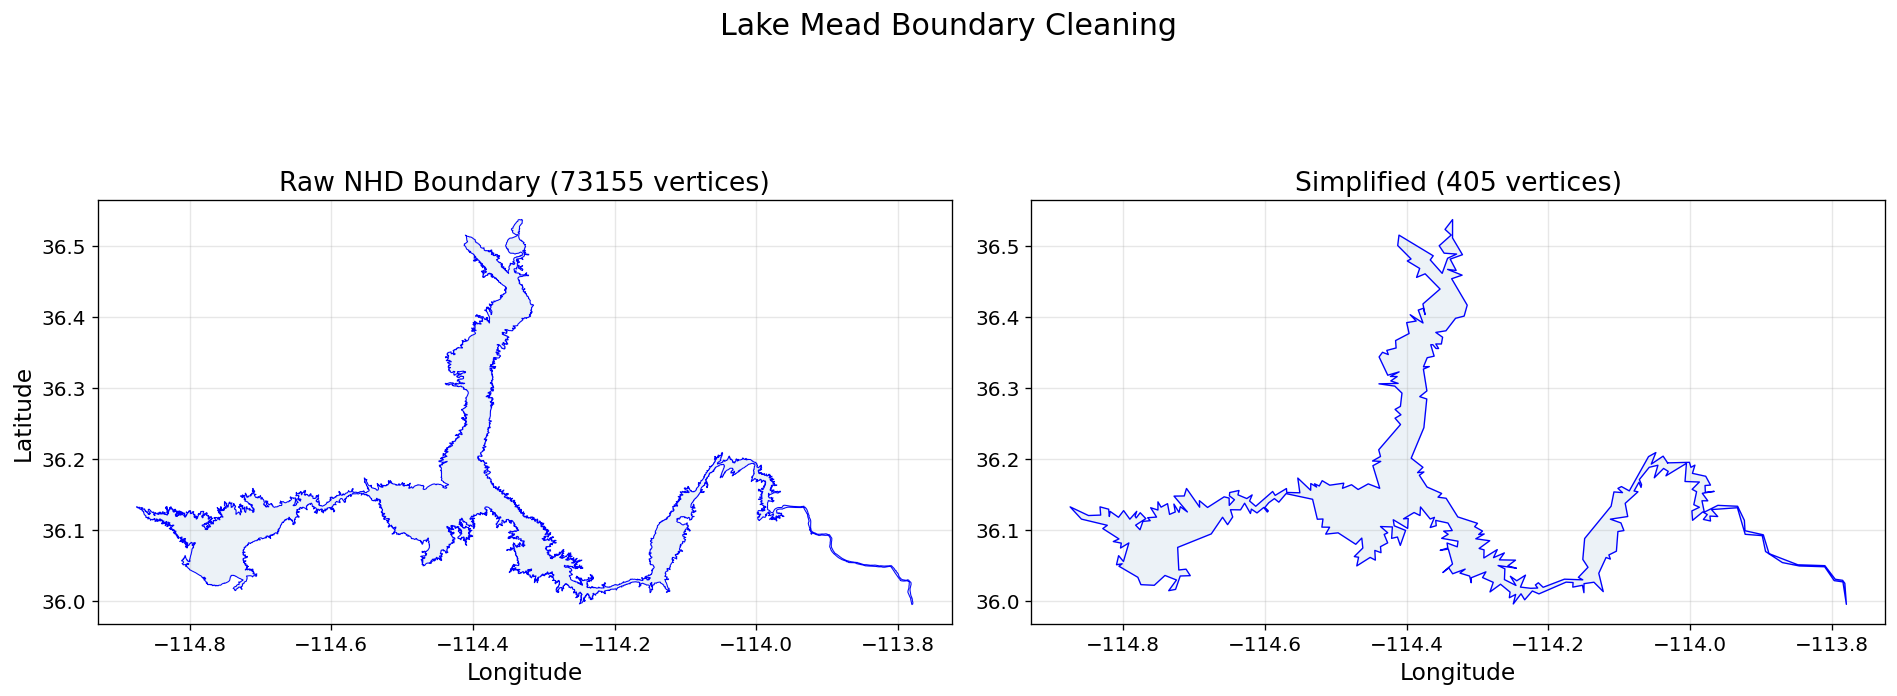


Using simplified boundary downstream (405 vertices).


In [5]:
# Simplify the polygon with Douglas-Peucker
raw_polygon = ShapelyPolygon(zip(lon, lat))

tolerance = 0.005  # ~450 m at this latitude
simplified = raw_polygon.simplify(tolerance, preserve_topology=True)

simple_coords = np.array(simplified.exterior.coords)
lon_simple = simple_coords[:, 0]
lat_simple = simple_coords[:, 1]

print(f'Vertices before simplification: {len(lon)}')
print(f'Vertices after simplification:  {len(lon_simple)}')

# --- Before / After comparison ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(lon, lat, 'b-', linewidth=0.6)
ax.fill(lon, lat, alpha=0.1, color='steelblue')
ax.set_title(f'Raw NHD Boundary ({len(lon)} vertices)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(lon_simple, lat_simple, 'b-', linewidth=0.8)
ax.fill(lon_simple, lat_simple, alpha=0.1, color='steelblue')
ax.set_title(f'Simplified ({len(lon_simple)} vertices)')
ax.set_xlabel('Longitude')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.suptitle('Lake Mead Boundary Cleaning', y=1.02)
plt.tight_layout()
plt.show()

# Replace lon/lat for downstream cells
lon = lon_simple
lat = lat_simple
print(f'\nUsing simplified boundary downstream ({len(lon)} vertices).')

### Saving Boundary Coordinates

In [6]:
# Save for any downstream notebook that wants to skip the NHD query
output_dir = Path('../data/boundaries')
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / 'lake_mead_boundary.csv'

boundary_df = pd.DataFrame({'longitude': lon, 'latitude': lat})
boundary_df.to_csv(output_path, index=False)

print(f'Saved {len(boundary_df)} boundary points to {output_path}')

Saved 405 boundary points to ..\data\boundaries\lake_mead_boundary.csv


## 4. Fitting the Spline Boundary

Same SplineBoundary class as Notebook 02. The spline gives us a continuous parameterization of the lake's perimeter, which is what we need for the arc-length parameter $s$.

Total arc length: 6.6980 degrees
Parameter range: (0.0, 1.0)

Start point (t=0): (-114.0317, 36.1944)
End point (t=1):   (-114.0317, 36.1944)
Start approx End: True


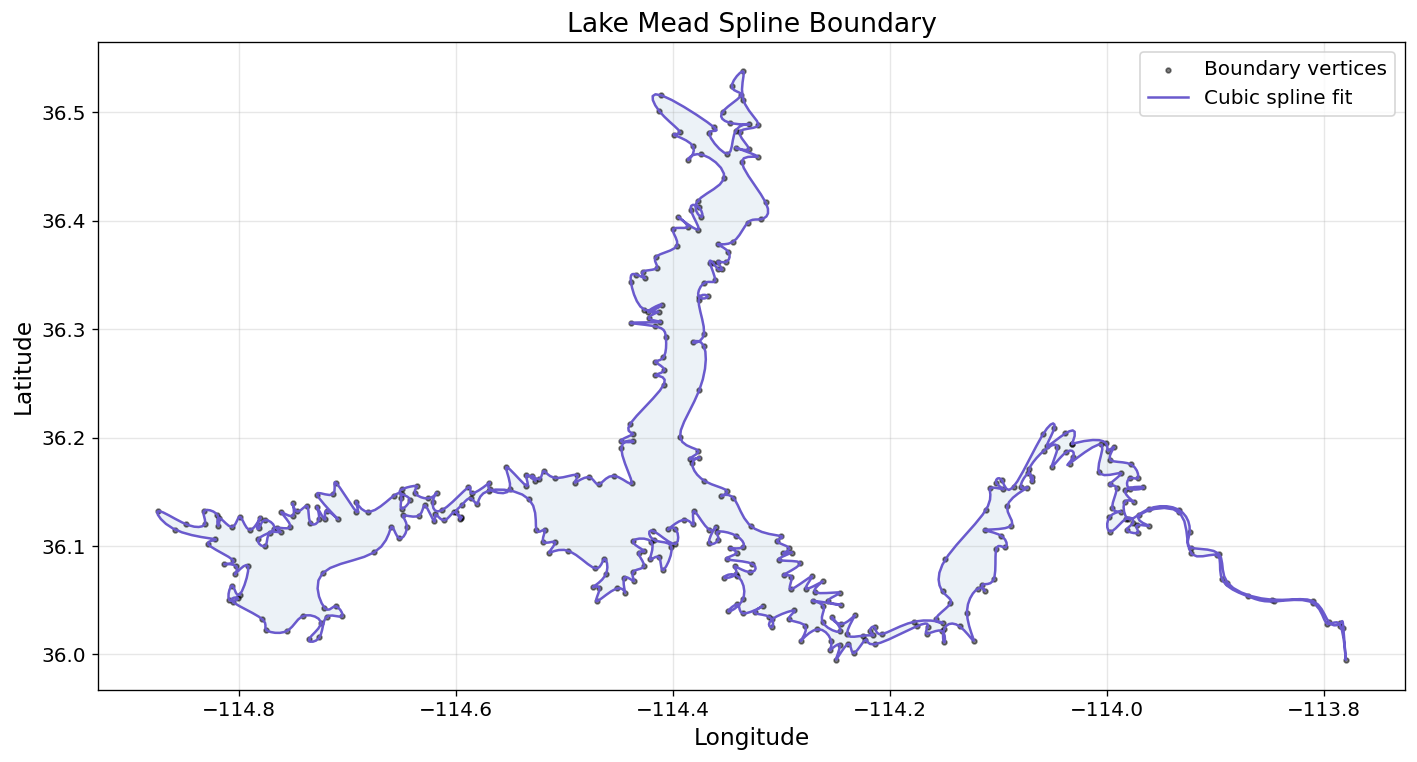

In [7]:
boundary = SplineBoundary(x_coords=lon, y_coords=lat)

L = boundary.total_arc_length()
print(f'Total arc length: {L:.4f} degrees')
print(f'Parameter range: {boundary.t_range()}')

start_pt = boundary.evaluate(0.0)
end_pt = boundary.evaluate(1.0)
print(f'\nStart point (t=0): ({start_pt[0]:.4f}, {start_pt[1]:.4f})')
print(f'End point (t=1):   ({end_pt[0]:.4f}, {end_pt[1]:.4f})')
print(f'Start approx End: {np.allclose(start_pt, end_pt, atol=1e-3)}')

# Sample the spline for visualization
spline_pts = boundary.sample_boundary(n_points=2000)   # more points than Tahoe; bigger lake

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(lon, lat, c='black', s=8, alpha=0.5, zorder=2, label='Boundary vertices')
ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='slateblue', linewidth=1.5,
        zorder=3, label='Cubic spline fit')
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Lake Mead Spline Boundary')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Loading Wildfire Data

Same source as Notebook 03: the FPA FOD SQLite database. We pull fires within a generous bounding box around Lake Mead, then keep only those within the lake's vicinity.

Bounding box rationale: Lake Mead spans roughly $36.0\degree\text{N}$ to $36.4\degree\text{N}$ and $-114.8\degree\text{W}$ to $-113.9\degree\text{W}$. We pad by about 0.2 degrees on all sides (~20 km) to capture fires close enough to the lake that the boundary could influence their clustering.

For this MVP, we don't filter to a specific administrative boundary (like TRPA in Notebook 03). A bounding box is sufficient to answer the core question; if the analysis continues, we can swap in the NPS Lake Mead National Recreation Area polygon for a more rigorous study area.

In [8]:
# Bounding box around Lake Mead
LAT_MIN, LAT_MAX = 35.8, 36.6
LON_MIN, LON_MAX = -115.0, -113.7

db_path = '../data/raw/fires.sqlite'

query = """
    SELECT LATITUDE, LONGITUDE, FIRE_SIZE, NWCG_GENERAL_CAUSE,
           NWCG_CAUSE_CLASSIFICATION, FIRE_YEAR, DISCOVERY_DOY
    FROM Fires
    WHERE LATITUDE BETWEEN ? AND ?
      AND LONGITUDE BETWEEN ? AND ?
"""

with sqlite3.connect(db_path) as conn:
    fires_raw = pd.read_sql_query(
        query, conn,
        params=(LAT_MIN, LAT_MAX, LON_MIN, LON_MAX),
    )

print(f'Fires in SQL bounding box: {len(fires_raw)}')
print(f'Year range: {fires_raw["FIRE_YEAR"].min()}-{fires_raw["FIRE_YEAR"].max()}')
print(f'\nCause breakdown:')
print(fires_raw['NWCG_GENERAL_CAUSE'].value_counts().to_string())

Fires in SQL bounding box: 1059
Year range: 1992-2020

Cause breakdown:
NWCG_GENERAL_CAUSE
Natural                                       493
Missing data/not specified/undetermined       215
Equipment and vehicle use                     102
Recreation and ceremony                        64
Debris and open burning                        45
Fireworks                                      36
Arson/incendiarism                             35
Smoking                                        31
Firearms and explosives use                    21
Misuse of fire by a minor                      10
Other causes                                    4
Power generation/transmission/distribution      2
Railroad operations and maintenance             1


## 6. Data Cleaning and Feature Engineering

Same cleaning recipe as Notebook 03:

1. Drop fires with missing cause (consistent with the Tahoe analysis).
2. Encode cause as binary (0 = Natural / lightning, 1 = Human-caused).
3. Project each fire onto the lake boundary to get $(t, s)$ parameters.

We keep the cause and fire size attributes on the cleaned data so we can compute $\sigma_a$ for the clusters as a side observation, even though we won't cluster on attributes in this notebook.

In [9]:
# Filter out missing cause
fires = fires_raw[
    fires_raw['NWCG_GENERAL_CAUSE'] != 'Missing data/not specified/undetermined'
].copy().reset_index(drop=True)

print(f'Fires after filtering missing cause: {len(fires)}')

# Encode cause as binary: 0 = Natural, 1 = Human-caused
fires['cause_binary'] = (fires['NWCG_GENERAL_CAUSE'] != 'Natural').astype(int)

# Log-transform fire size (heavy right-tail; one fire at 44,707 acres)
fires['fire_size_log'] = np.log1p(fires['FIRE_SIZE'].values)

print(f'\nCause classification:')
print(f"  Natural (lightning): {(fires['cause_binary'] == 0).sum()}")
print(f"  Human-caused:        {(fires['cause_binary'] == 1).sum()}")

print(f'\nFire size (acres):')
print(f"  Min:    {fires['FIRE_SIZE'].min():.4f}")
print(f"  Median: {fires['FIRE_SIZE'].median():.2f}")
print(f"  Mean:   {fires['FIRE_SIZE'].mean():.2f}")
print(f"  Max:    {fires['FIRE_SIZE'].max():.2f}")

Fires after filtering missing cause: 844

Cause classification:
  Natural (lightning): 493
  Human-caused:        351

Fire size (acres):
  Min:    0.1000
  Median: 0.10
  Mean:   484.55
  Max:    44707.00


### Projecting Fires onto the Lake Boundary

For each fire, find the point on the spline boundary closest to it. This gives `t` (the spline parameter) and `s` (the arc-length parameter), which is what makes obstacle-aware $k$-means obstacle-aware.

This is the slow step. On the first run it takes a couple of minutes; subsequent runs load from the pickle cache.

In [10]:
def project_all_fires():
    print('Projecting fire locations onto lake boundary...')
    lons = fires['LONGITUDE'].values
    lats = fires['LATITUDE'].values
    n = len(fires)

    t_arr = np.zeros(n)
    s_arr = np.zeros(n)
    for idx in range(n):
        if idx % 200 == 0:
            print(f'  {idx}/{n} ({100*idx/n:.0f}%)')
        t_arr[idx], s_arr[idx] = boundary.project_point(lons[idx], lats[idx])
    return t_arr, s_arr


t_values, s_values = cached_or_run(
    cache_dir / 'mead_fire_projections.pkl',
    project_all_fires,
)

fires['t_param'] = t_values
fires['s_param'] = s_values

print(f'Projection complete: {len(fires)} fires projected')
print(f's range: [{fires["s_param"].min():.4f}, {fires["s_param"].max():.4f}]')

Computing (will cache to mead_fire_projections.pkl)...
Projecting fire locations onto lake boundary...
  0/844 (0%)
  200/844 (24%)
  400/844 (47%)
  600/844 (71%)
  800/844 (95%)
Projection complete: 844 fires projected
s range: [0.0039, 0.9981]


### Building the Feature Matrix

Matches Notebook 03's structure. Min-Max scaling on geographic coordinates and log-transformed fire size; $s$ is already in $[0, 1]$ from the spline parameterization; $\texttt{cause\_binary}$ is already 0 or 1.

The full feature matrix $X$ will be used downstream. For Tier 1 (this notebook's MVP test), we use $X[:, :3]$ (geography + arc-length, no attributes).

In [11]:
# Geographic coordinates: Min-Max scale to [0, 1]
scaler_xy = MinMaxScaler()
xy_scaled = scaler_xy.fit_transform(fires[['LONGITUDE', 'LATITUDE']].values)

# Fire size (log): Min-Max scale to [0, 1]
scaler_size = MinMaxScaler()
fire_size_scaled = scaler_size.fit_transform(fires[['fire_size_log']].values)

# Assemble feature matrix matching Notebook 03's structure:
# [x_scaled, y_scaled, s, fire_size_scaled, cause_binary]
X = np.column_stack([
    xy_scaled,                          # columns 0, 1: geographic
    fires['s_param'].values,            # column 2: arc-length
    fire_size_scaled.ravel(),           # column 3: fire size (log + normalized)
    fires['cause_binary'].values        # column 4: cause type
])

feature_names = ['x_scaled', 'y_scaled', 's', 'fire_size', 'cause_type']

print(f'Feature matrix shape: {X.shape}')
print(f'Features: {feature_names}')
print(f'\nFirst 5 rows:')
print(np.array2string(X[:5], precision=4, suppress_small=True))

Feature matrix shape: (844, 5)
Features: ['x_scaled', 'y_scaled', 's', 'fire_size', 'cause_type']

First 5 rows:
[[0.2103 0.7729 0.5596 0.     1.    ]
 [0.3584 0.2084 0.3533 0.0563 1.    ]
 [0.3199 0.2084 0.4341 0.0082 1.    ]
 [0.8648 0.125  0.073  0.     0.    ]
 [0.8738 0.2    0.0902 0.5939 0.    ]]


### Saving the Cleaned Data

In [12]:
processed_dir = Path('../data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)
processed_path = processed_dir / 'mead_fires_processed.csv'
fires.to_csv(processed_path, index=False)
print(f'Saved {len(fires)} fires to {processed_path}')

Saved 844 fires to ..\data\processed\mead_fires_processed.csv


## 7. Visualizing the Raw Data

Before any clustering, see the fires laid out against the lake boundary. The visual should make it intuitive whether $s$ would be useful here: are there clusters of fires on opposite shores that look like they should be separate but are close in lat/lon?

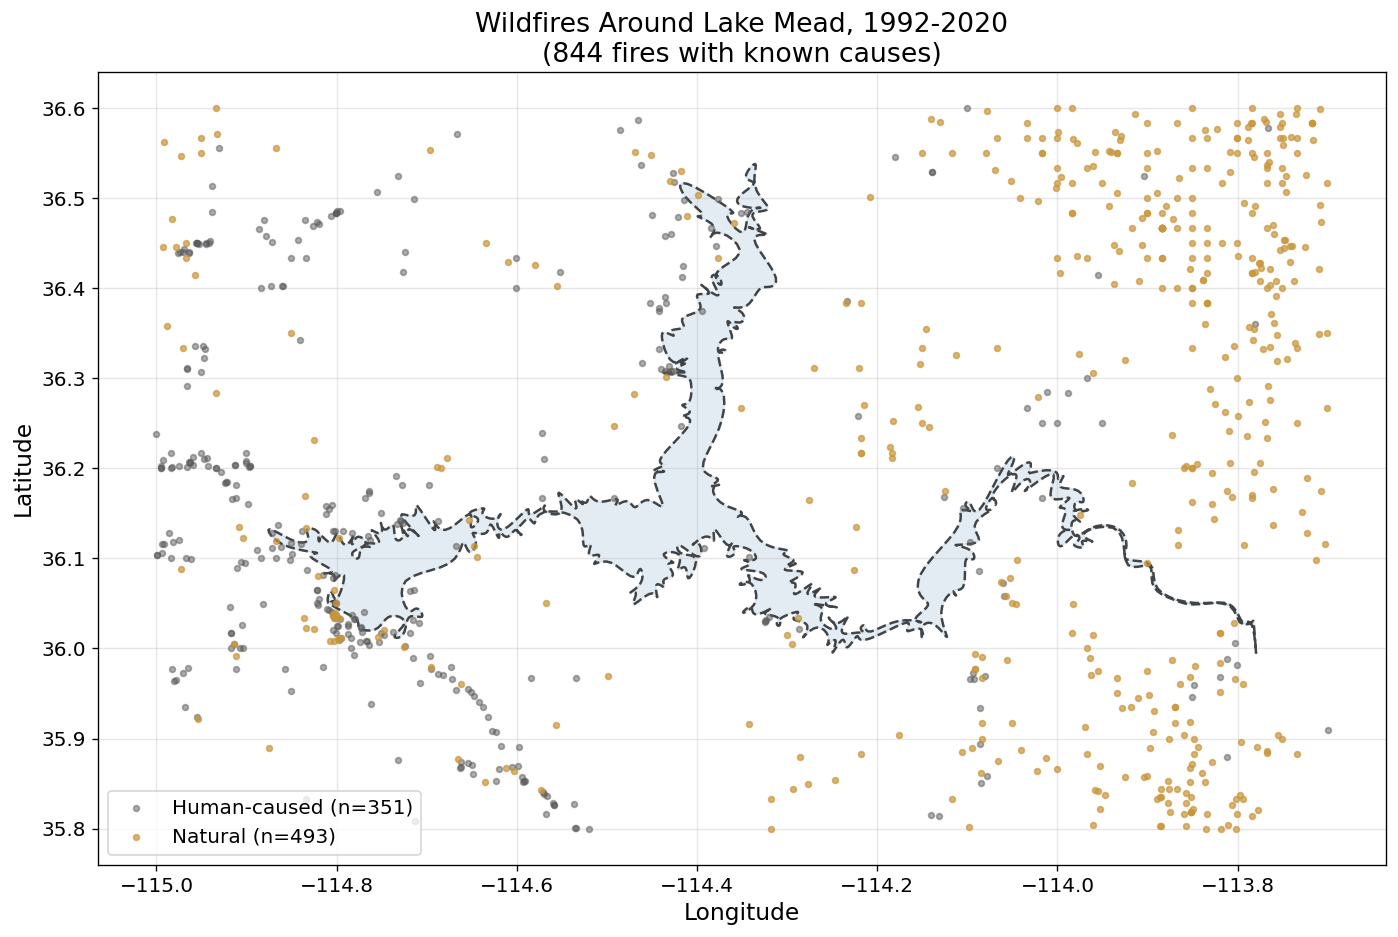

In [13]:
fig, ax = plt.subplots(figsize=(14, 8))

# Lake boundary
ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.15, color='steelblue')

# Fires colored by cause for visual interest
human = fires['cause_binary'] == 1
natural = ~human
ax.scatter(fires.loc[human, 'LONGITUDE'], fires.loc[human, 'LATITUDE'],
           c='#5a5a5a', s=12, alpha=0.5, label=f'Human-caused (n={human.sum()})',
           zorder=2)
ax.scatter(fires.loc[natural, 'LONGITUDE'], fires.loc[natural, 'LATITUDE'],
           c='#c9963b', s=12, alpha=0.7, label=f'Natural (n={natural.sum()})',
           zorder=3)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Wildfires Around Lake Mead, {fires["FIRE_YEAR"].min()}-{fires["FIRE_YEAR"].max()}'
             f'\n({len(fires)} fires with known causes)')
ax.legend(loc='best')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Three-Way Clustering Comparison (Full Dataset)

Three clusterings on the same data ($k=4$, all 844 fires, XY + $s$, no attributes):

1. **Standard $k$-means** on scaled $(x, y)$ only. Baseline. No knowledge of the lake.
2. **Obstacle-aware $k$-means at equal weights** ($\beta = 1$, $\gamma = 0$). The algorithm knows about the lake at a fixed strength.
3. **Obstacle-aware $k$-means at optimized $\beta$** ($\gamma = 0$). Sweep $\beta$ over a 1D grid.

All three use the same feature subset for fair comparison:
- Standard $k$-means uses scaled $(x, y)$: `X[:, :2]`
- Obstacle-aware uses scaled $(x, y, s)$: `X[:, :3]` plus `t_data` for the boundary parameterization

This matches Notebook 03's Tier 1 conventions.

### 8.1 Standard k-Means (baseline)

In [15]:
k = 4

# Standard k-Means on scaled (x, y) -- matches Notebook 03 Tier 1
model_std = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_std = model_std.fit_predict(X[:, :2])

spans_std = [arc_length_span(fires['s_param'].values[labels_std == c]) for c in range(k)]
sigma_std, _ = attribute_separation(X, labels_std, k, attr_indices=[3, 4])

print(f'Standard k-Means converged in {model_std.n_iter_} iterations')
print(f'\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_std == i)} fires')
print(f'\nMean arc-length span: {np.mean(spans_std):.4f}')
print(f'σ_a:                  {sigma_std:.4f}')

Standard k-Means converged in 7 iterations

Cluster sizes:
  Cluster 1: 185 fires
  Cluster 2: 124 fires
  Cluster 3: 273 fires
  Cluster 4: 262 fires

Mean arc-length span: 0.3371
σ_a:                  0.6667


c:\Users\mpp24\anaconda3\envs\obstacle-clustering\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


### 8.2 Obstacle-Aware k-Means at Equal Weights

In [16]:
# Equal-weight obstacle-aware: alpha = beta = 1, gamma = 0 (no attributes)
# OA equal weights: 3-column feature matrix + t_data
model_eq = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=1.0, gamma=0.0,
    random_state=42, n_attr=0
)
model_eq.fit(X[:, :3], t_data=fires['t_param'].values)
labels_eq = model_eq.labels_

spans_eq = [arc_length_span(fires['s_param'].values[labels_eq == c]) for c in range(k)]
sigma_eq, _ = attribute_separation(X, labels_eq, k, attr_indices=[3, 4])

print(f'OA equal weights: converged in {model_eq.n_iter_} iterations')
print(f'\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_eq == i)} fires')
print(f'\nMean arc-length span: {np.mean(spans_eq):.4f}')
print(f'σ_a:                  {sigma_eq:.4f}')

OA equal weights: converged in 8 iterations

Cluster sizes:
  Cluster 1: 274 fires
  Cluster 2: 261 fires
  Cluster 3: 125 fires
  Cluster 4: 184 fires

Mean arc-length span: 0.3371
σ_a:                  0.6667


### 8.3 Obstacle-Aware k-Means at Optimized β

A 1D grid search over $\beta$ at $\gamma = 0$. The cached pickle skips recomputation on later runs.

In [22]:
# Run the grid search and report the J-minimum, but don't refit yet
def compute_mead_beta_sweep():
    print('Computing Lake Mead objective surface (1D beta sweep)...')
    n_grid = 30
    beta_vals = np.linspace(0.05, 2.0, n_grid)
    J_vals = np.zeros(n_grid)
    for i, b in enumerate(beta_vals):
        J_vals[i] = objective_function(
            (1.0, b, 0.0),
            X[:, :3], fires['t_param'].values, boundary,
            k=k, n_attr=0, attr_indices=[], random_state=42
        )
    return beta_vals, J_vals


beta_grid, J_vals = cached_or_run(
    cache_dir / 'mead_beta_sweep.pkl',
    compute_mead_beta_sweep,
)

# Report where the J-minimum lands, for reference
i_min = J_vals.argmin()
j_min_beta = beta_grid[i_min]
j_min_J = J_vals[i_min]

print(f'J-minimum on grid: β = {j_min_beta:.4f}, J = {j_min_J:.4f}')
print(f'\nInspect the J / span plot to choose your β, then run the next cell.')

Loading cached: mead_beta_sweep.pkl
J-minimum on grid: β = 1.1259, J = 1.0411

Inspect the J / span plot to choose your β, then run the next cell.


### 8.4 Objective and Span Across β

The $\beta$ sweep with span overlaid. If $J$ is flat across a range of $\beta$ values, multiple clusterings give equivalent objective values; we can then choose $\beta$ within that range to optimize for span specifically.

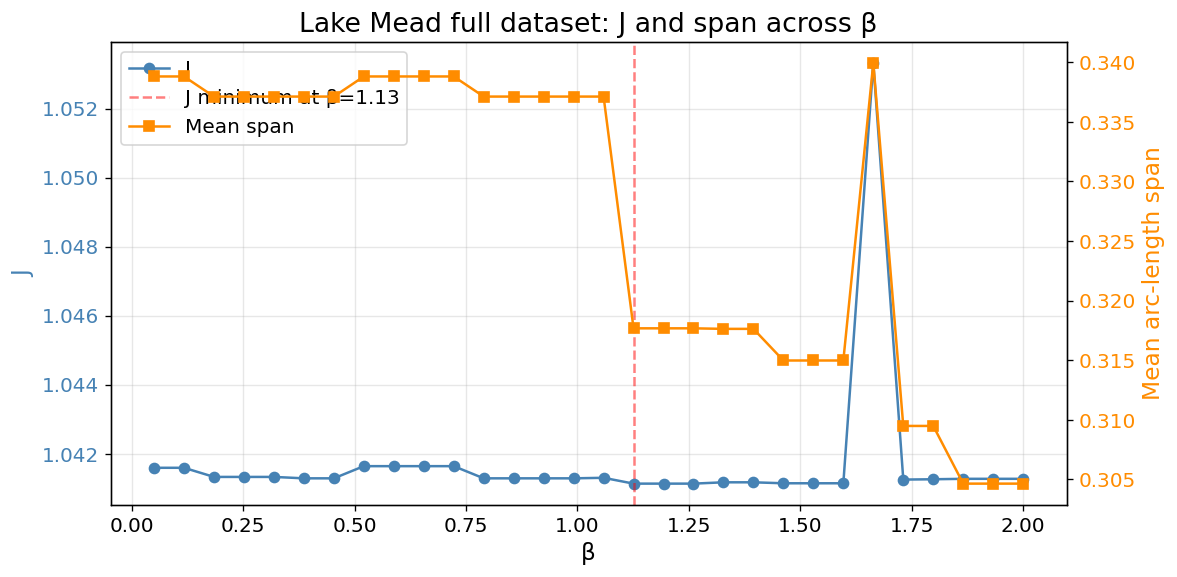

In [18]:
# Compute span at each beta in the grid (for the overlay plot)
spans_by_beta = []
for b in beta_grid:
    model_b = ObstacleKMeans(
        k=k, boundary=boundary,
        alpha=1.0, beta=b, gamma=0.0,
        random_state=42, n_attr=0
    )
    model_b.fit(X[:, :3], t_data=fires['t_param'].values)
    spans_b = [arc_length_span(fires['s_param'].values[model_b.labels_ == c]) for c in range(k)]
    spans_by_beta.append(np.mean(spans_b))
spans_by_beta = np.array(spans_by_beta)


fig, ax1 = plt.subplots(figsize=(10, 5))

color_J = 'steelblue'
ax1.plot(beta_grid, J_vals, 'o-', color=color_J, label='J')
ax1.set_xlabel('β')
ax1.set_ylabel('J', color=color_J)
ax1.tick_params(axis='y', labelcolor=color_J)

ax2 = ax1.twinx()
color_span = 'darkorange'
ax2.plot(beta_grid, spans_by_beta, 's-', color=color_span, label='Mean span')
ax2.set_ylabel('Mean arc-length span', color=color_span)
ax2.tick_params(axis='y', labelcolor=color_span)

ax1.axvline(opt_beta, color='red', linestyle='--', alpha=0.5,
            label=f'J minimum at β={opt_beta:.2f}')

ax1.set_title('Lake Mead full dataset: J and span across β')
ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.show()

In [40]:
# Set your chosen beta here after inspecting the J / span plot
opt_beta = 1.9   # <-- edit this value

# Refit at the chosen beta
model_opt = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=opt_beta, gamma=0.0,
    random_state=42, n_attr=0
)
model_opt.fit(X[:, :3], t_data=fires['t_param'].values)
labels_opt = model_opt.labels_

spans_opt = [arc_length_span(fires['s_param'].values[labels_opt == c]) for c in range(k)]
sigma_opt, _ = attribute_separation(X, labels_opt, k, attr_indices=[3, 4])

# Find J at the chosen beta by looking it up in the grid (nearest point)
nearest_idx = np.argmin(np.abs(beta_grid - opt_beta))
nearest_J = J_vals[nearest_idx]
nearest_beta = beta_grid[nearest_idx]

print(f'Selected beta: {opt_beta}')
print(f'(Nearest grid point: β = {nearest_beta:.4f}, J = {nearest_J:.4f})')
if abs(opt_beta - j_min_beta) > 1e-6:
    print(f'Note: J-minimum was at β = {j_min_beta:.4f}; you chose β = {opt_beta}')
print(f'\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_opt == i)} fires')
print(f'\nMean arc-length span: {np.mean(spans_opt):.4f}')
print(f'σ_a:                  {sigma_opt:.4f}')

Selected beta: 1.9
(Nearest grid point: β = 1.9328, J = 1.0413)
Note: J-minimum was at β = 1.1259; you chose β = 1.9

Cluster sizes:
  Cluster 1: 278 fires
  Cluster 2: 259 fires
  Cluster 3: 126 fires
  Cluster 4: 181 fires

Mean arc-length span: 0.3046
σ_a:                  0.6667


## 9. Side-by-Side Comparison (Full Dataset)

This is the visual that answers the question. If $s$ is doing its job, the optimized $\beta$ version should produce clusters that respect the lake -- you should see cluster boundaries running through the water rather than spanning it.

Cluster colors are arbitrary here (no basin reference to align against in this MVP). If we proceed to a full analysis, we'd add label alignment so colors are consistent across plots.

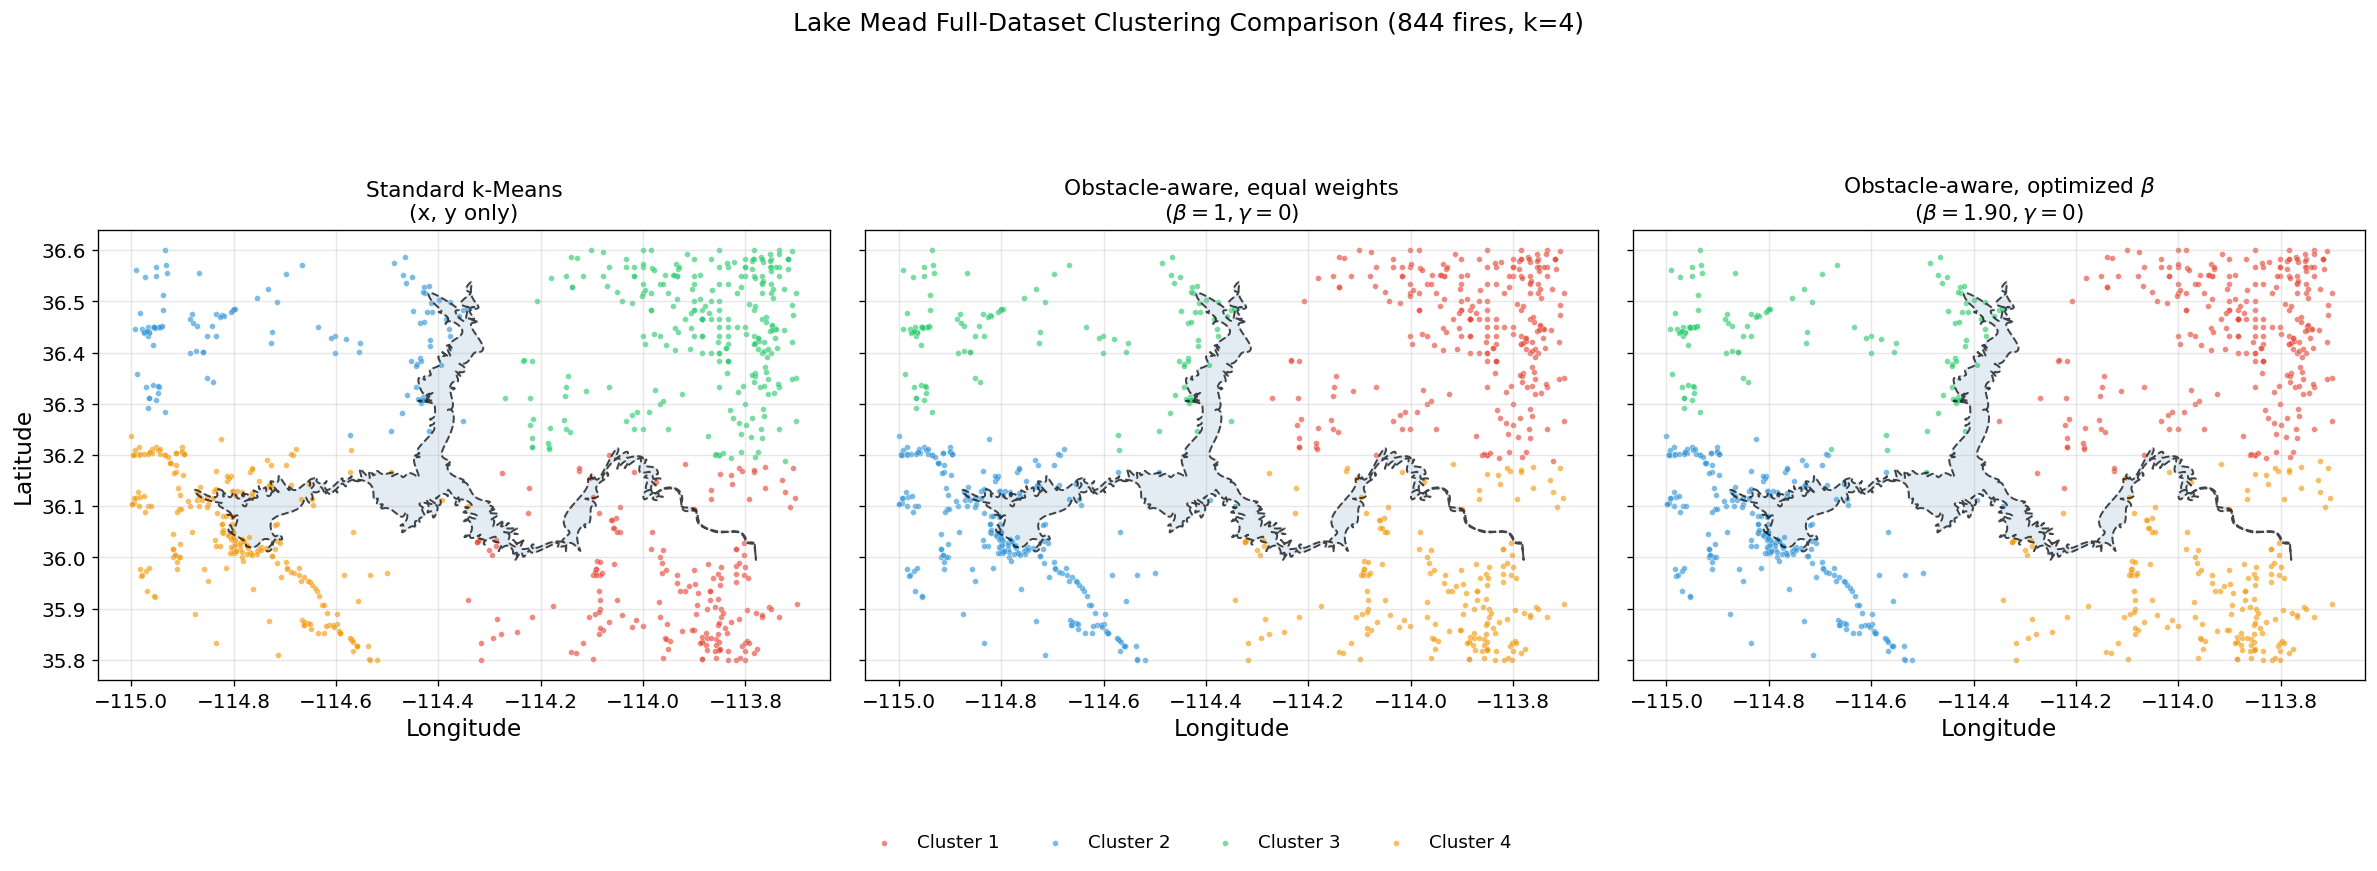

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharex=True, sharey=True)

for ax, labels, title in [
    (axes[0], labels_std, 'Standard k-Means\n(x, y only)'),
    (axes[1], labels_eq,
     rf'Obstacle-aware, equal weights' + '\n' + rf'($\beta = 1, \gamma = 0$)'),
    (axes[2], labels_opt,
     rf'Obstacle-aware, optimized $\beta$' + '\n' + rf'($\beta = {opt_beta:.2f}, \gamma = 0$)'),
]:
    ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
            linewidth=1.2, alpha=0.7)
    ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.15, color='steelblue')

    for i in range(k):
        mask = labels == i
        ax.scatter(fires['LONGITUDE'].values[mask],
                   fires['LATITUDE'].values[mask],
                   c=CLUSTER_COLORS[i], s=12, alpha=0.65,
                   label=f'Cluster {i+1}', edgecolors='white', linewidth=0.2)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Longitude')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Latitude')

handles, leg_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, leg_labels, loc='lower center', ncol=k,
           bbox_to_anchor=(0.5, -0.02), frameon=False, fontsize=11)

fig.suptitle(f'Lake Mead Full-Dataset Clustering Comparison ({len(fires)} fires, k={k})',
             fontsize=15, y=1.00)
plt.tight_layout()
plt.show()

### Comparison Statistics

In [42]:
span_pct_eq = 100 * (np.mean(spans_std) - np.mean(spans_eq)) / np.mean(spans_std)
span_pct_opt = 100 * (np.mean(spans_std) - np.mean(spans_opt)) / np.mean(spans_std)

print('Lake Mead full-dataset clustering comparison (no attributes, isolating s):')
print()
print(f'  Standard k-Means on scaled XY:')
print(f'    span = {np.mean(spans_std):.4f}, σ_a = {sigma_std:.4f}')
print()
print(f'  Obstacle-aware, equal weights (β = 1, γ = 0):')
print(f'    span = {np.mean(spans_eq):.4f}, σ_a = {sigma_eq:.4f}')
print(f'    vs standard: span {span_pct_eq:+.1f}%')
print()
print(f'  Obstacle-aware, optimized β = {opt_beta:.4f} (γ = 0):')
print(f'    span = {np.mean(spans_opt):.4f}, σ_a = {sigma_opt:.4f}')
print(f'    vs standard: span {span_pct_opt:+.1f}%')

Lake Mead full-dataset clustering comparison (no attributes, isolating s):

  Standard k-Means on scaled XY:
    span = 0.3371, σ_a = 0.6667

  Obstacle-aware, equal weights (β = 1, γ = 0):
    span = 0.3371, σ_a = 0.6667
    vs standard: span +0.0%

  Obstacle-aware, optimized β = 1.9000 (γ = 0):
    span = 0.3046, σ_a = 0.6667
    vs standard: span +9.6%


## 10. How Close Are the Fires to the Lake?

Before running the near-shore analysis, check how many fires fall within various distances of the lake. This tells us whether the near-shore subset will be statistically viable.

In [27]:
# Compute each fire's straight-line distance to its boundary projection
# (approximate degree-to-km conversion at this latitude, ~36°N)
distances_to_lake_km = np.zeros(len(fires))
for i, t in enumerate(fires['t_param'].values):
    proj = boundary.evaluate(t)
    lon_diff = fires['LONGITUDE'].iloc[i] - proj[0]
    lat_diff = fires['LATITUDE'].iloc[i] - proj[1]
    # At latitude ~36, 1 deg lat is about 111 km and 1 deg lon is about 90 km
    distances_to_lake_km[i] = np.sqrt((lon_diff * 90)**2 + (lat_diff * 111)**2)

fires['dist_to_lake_km'] = distances_to_lake_km

print('Fire distance distribution (km from Lake Mead shore):')
for thr in [1, 2, 5, 10]:
    n = (fires['dist_to_lake_km'] < thr).sum()
    print(f'  Within {thr:2d} km: {n:4d} fires ({100*n/len(fires):.1f}%)')
print(f'  Total: {len(fires)} fires')

Fire distance distribution (km from Lake Mead shore):
  Within  1 km:   97 fires (11.5%)
  Within  2 km:  134 fires (15.9%)
  Within  5 km:  208 fires (24.6%)
  Within 10 km:  301 fires (35.7%)
  Total: 844 fires


## 11. Near-Shore Subset Analysis

The full-dataset comparison in Section 9 includes many fires too far from the lake for the obstacle parameter to physically influence their clustering. Restricting to fires within 5 km of shore should concentrate the obstacle's effect on the comparison.

The 5 km threshold gives a manageable subset size while keeping the spatial scope physically meaningful. At this distance, fires are still in the lake's immediate watershed and recreation zone; beyond 5 km, you're well into desert that has no functional relationship to the lake.

### 11.1 Filtering to the Near-Shore Subset

In [28]:
# Filter to fires within 5 km of shore
threshold_km = 5
near_mask = fires['dist_to_lake_km'].values < threshold_km
n_near = int(near_mask.sum())

print(f'Near-shore subset: fires within {threshold_km} km of Lake Mead')
print(f'  {n_near}/{len(fires)} fires '
      f'({100*n_near/len(fires):.1f}% of full dataset)')
print(f'  ~{n_near/k:.0f} fires per cluster at k={k}')

# Subset the feature matrix and projection arrays
X_near = X[near_mask]                             # 5-column feature matrix
t_near = fires['t_param'].values[near_mask]
s_near = fires['s_param'].values[near_mask]
fires_near = fires[near_mask].copy().reset_index(drop=True)

print(f'\nCause classification in near-shore subset:')
print(f"  Natural (lightning): {(fires_near['cause_binary'] == 0).sum()}")
print(f"  Human-caused:        {(fires_near['cause_binary'] == 1).sum()}")

Near-shore subset: fires within 5 km of Lake Mead
  208/844 fires (24.6% of full dataset)
  ~52 fires per cluster at k=4

Cause classification in near-shore subset:
  Natural (lightning): 63
  Human-caused:        145


### Visualizing the Near-Shore Subset

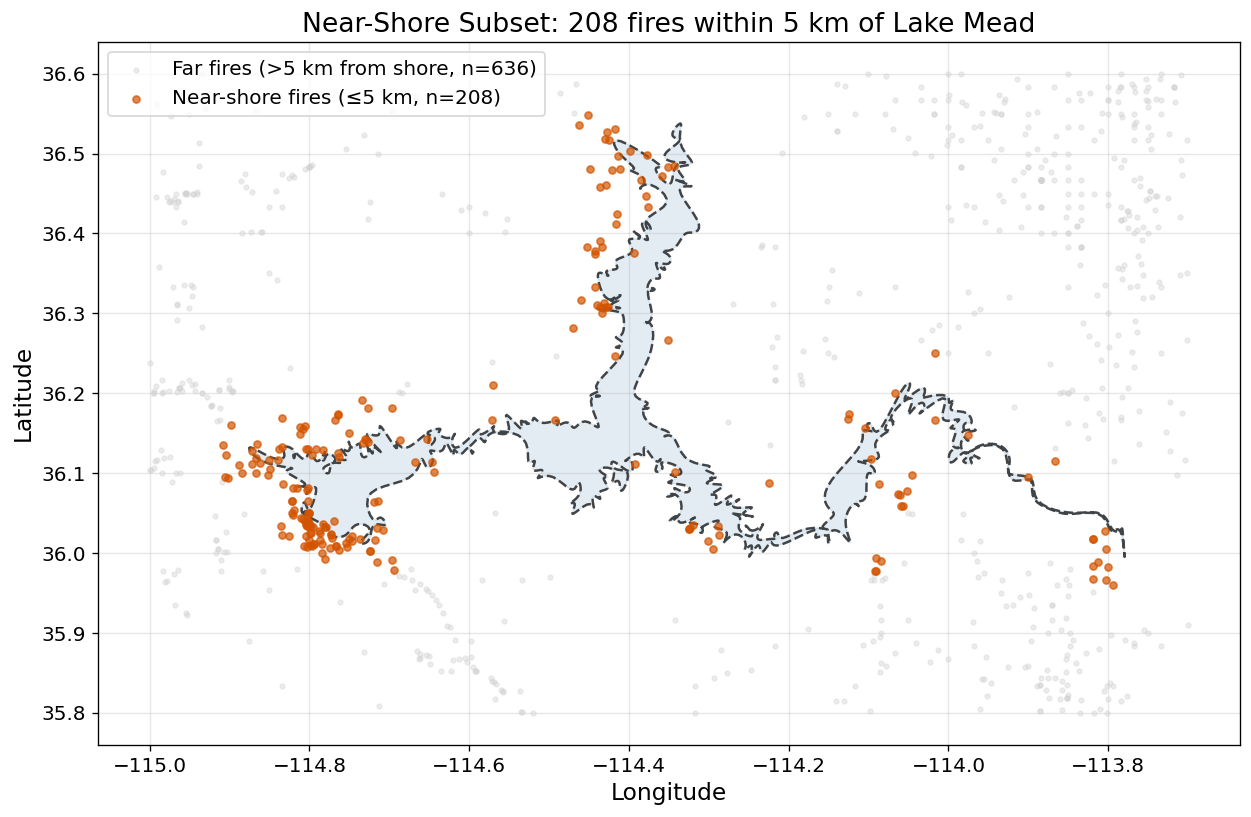

In [29]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.15, color='steelblue')

# Far fires grayed for context
far_mask = ~near_mask
ax.scatter(fires['LONGITUDE'].values[far_mask],
           fires['LATITUDE'].values[far_mask],
           c='lightgray', s=8, alpha=0.4, zorder=2,
           label=f'Far fires (>{threshold_km} km from shore, n={far_mask.sum()})')

# Near-shore fires highlighted
ax.scatter(fires_near['LONGITUDE'].values,
           fires_near['LATITUDE'].values,
           c='#d35400', s=18, alpha=0.7, zorder=3,
           label=f'Near-shore fires (≤5 km, n={n_near})')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Near-Shore Subset: {n_near} fires within {threshold_km} km of Lake Mead')
ax.legend(loc='best')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 11.2 Three-Way Clustering on the Near-Shore Subset

Same three methods as Section 8, applied to the near-shore subset. All clustering uses 3-column feature matrices for obstacle-aware methods (matching Notebook 03's Tier 1 conventions).

In [30]:
# --- Method 1: Standard k-Means on scaled XY ---
model_std_near = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_std_near = model_std_near.fit_predict(X_near[:, :2])

spans_std_near = [arc_length_span(s_near[labels_std_near == c]) for c in range(k)]
sigma_std_near, _ = attribute_separation(X_near, labels_std_near, k, attr_indices=[3, 4])

print(f'Standard k-Means on near-shore subset:')
print(f'  Converged in {model_std_near.n_iter_} iterations')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_std_near == i)} fires')
print(f'  Mean arc-length span: {np.mean(spans_std_near):.4f}')
print(f'  σ_a:                  {sigma_std_near:.4f}')

Standard k-Means on near-shore subset:
  Converged in 4 iterations
  Cluster 1: 40 fires
  Cluster 2: 126 fires
  Cluster 3: 30 fires
  Cluster 4: 12 fires
  Mean arc-length span: 0.2110
  σ_a:                  0.3333


In [31]:
# --- Method 2: Obstacle-aware k-Means at equal weights (3-col + t_data) ---
model_eq_near = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=1.0, gamma=0.0,
    random_state=42, n_attr=0
)
model_eq_near.fit(X_near[:, :3], t_data=t_near)
labels_eq_near = model_eq_near.labels_

spans_eq_near = [arc_length_span(s_near[labels_eq_near == c]) for c in range(k)]
sigma_eq_near, _ = attribute_separation(X_near, labels_eq_near, k, attr_indices=[3, 4])

print(f'OA equal weights on near-shore subset:')
print(f'  Converged in {model_eq_near.n_iter_} iterations')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_eq_near == i)} fires')
print(f'  Mean arc-length span: {np.mean(spans_eq_near):.4f}')
print(f'  σ_a:                  {sigma_eq_near:.4f}')

OA equal weights on near-shore subset:
  Converged in 6 iterations
  Cluster 1: 48 fires
  Cluster 2: 40 fires
  Cluster 3: 42 fires
  Cluster 4: 78 fires
  Mean arc-length span: 0.2007
  σ_a:                  0.4167


In [34]:
# --- Method 3: Obstacle-aware k-Means at optimized beta ---
# Step 1: run the grid search and find the J-minimum (informational only)
def compute_mead_nearshore_beta_sweep():
    print('Computing near-shore objective surface (1D beta sweep)...')
    n_grid = 30
    beta_vals = np.linspace(0.05, 2.0, n_grid)
    J_vals = np.zeros(n_grid)
    for i, b in enumerate(beta_vals):
        J_vals[i] = objective_function(
            (1.0, b, 0.0),
            X_near[:, :3], t_near, boundary,
            k=k, n_attr=0, attr_indices=[], random_state=42
        )
    return beta_vals, J_vals


beta_grid_near, J_vals_near = cached_or_run(
    cache_dir / 'mead_nearshore_beta_sweep.pkl',
    compute_mead_nearshore_beta_sweep,
)

# Report where the J-minimum lands, for reference
i_min_near = J_vals_near.argmin()
j_min_beta_near = beta_grid_near[i_min_near]
j_min_J_near = J_vals_near[i_min_near]

print(f'J-minimum on grid: β = {j_min_beta_near:.4f}, J = {j_min_J_near:.4f}')
print(f'\nInspect the J / span plot below, then set opt_beta_near and run the refit.')

Loading cached: mead_nearshore_beta_sweep.pkl
J-minimum on grid: β = 0.2517, J = 1.0164

Inspect the J / span plot below, then set opt_beta_near and run the refit.


### 11.3 Objective and Span Across β (Near-Shore)

Same dual-axis plot as Section 8.4, but on the near-shore subset. The shape of these curves will tell us whether $\beta$ optimization is finding a real minimum or a flat region.

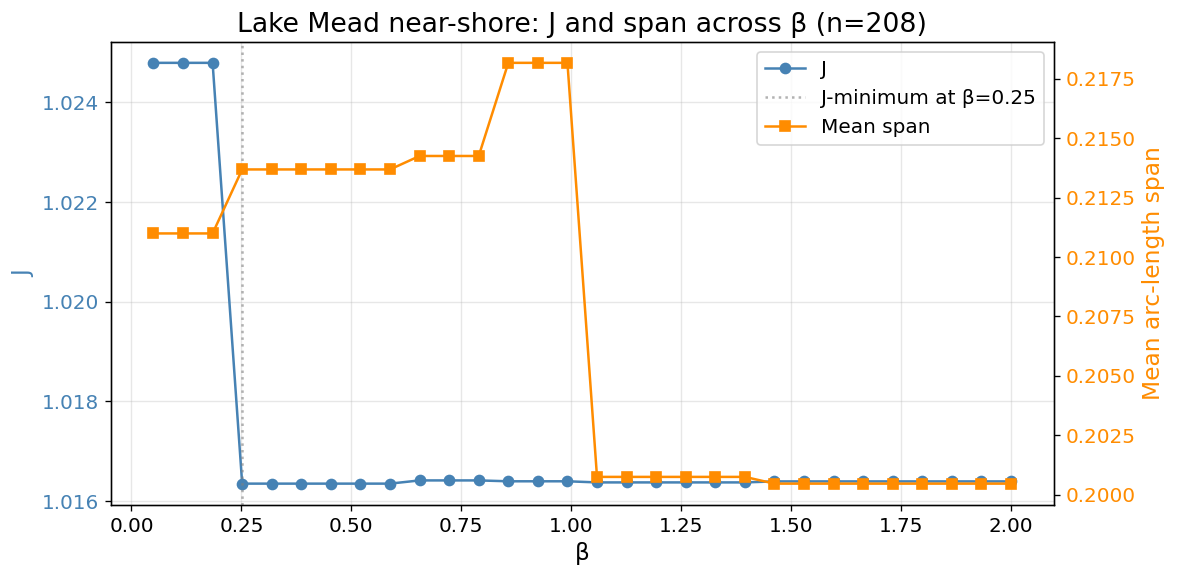

In [39]:
# Compute span at each beta in the grid (for the overlay plot)
spans_by_beta_near = []
for b in beta_grid_near:
    model_b = ObstacleKMeans(
        k=k, boundary=boundary,
        alpha=1.0, beta=b, gamma=0.0,
        random_state=42, n_attr=0
    )
    model_b.fit(X_near[:, :3], t_data=t_near)
    spans_b = [arc_length_span(s_near[model_b.labels_ == c]) for c in range(k)]
    spans_by_beta_near.append(np.mean(spans_b))
spans_by_beta_near = np.array(spans_by_beta_near)


fig, ax1 = plt.subplots(figsize=(10, 5))

color_J = 'steelblue'
ax1.plot(beta_grid_near, J_vals_near, 'o-', color=color_J, label='J')
ax1.set_xlabel('β')
ax1.set_ylabel('J', color=color_J)
ax1.tick_params(axis='y', labelcolor=color_J)

ax2 = ax1.twinx()
color_span = 'darkorange'
ax2.plot(beta_grid_near, spans_by_beta_near, 's-', color=color_span, label='Mean span')
ax2.set_ylabel('Mean arc-length span', color=color_span)
ax2.tick_params(axis='y', labelcolor=color_span)

ax1.axvline(j_min_beta_near, color='gray', linestyle=':', alpha=0.6,
            label=f'J-minimum at β={j_min_beta_near:.2f}')

ax1.set_title(f'Lake Mead near-shore: J and span across β (n={n_near})')
ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.show()

In [46]:
# Step 2: choose beta and refit at the chosen value
# Edit this after inspecting the plot above
opt_beta_near = 1.25   # <-- edit this

# Refit at the chosen beta
model_opt_near = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=opt_beta_near, gamma=0.0,
    random_state=42, n_attr=0
)
model_opt_near.fit(X_near[:, :3], t_data=t_near)
labels_opt_near = model_opt_near.labels_

spans_opt_near = [arc_length_span(s_near[labels_opt_near == c]) for c in range(k)]
sigma_opt_near, _ = attribute_separation(X_near, labels_opt_near, k, attr_indices=[3, 4])

# Find J at the chosen beta by looking it up in the grid (nearest point)
nearest_idx = np.argmin(np.abs(beta_grid_near - opt_beta_near))
nearest_J = J_vals_near[nearest_idx]
nearest_beta_grid = beta_grid_near[nearest_idx]

print(f'OA optimized beta on near-shore subset:')
print(f'  Selected β: {opt_beta_near}')
print(f'  (Nearest grid point: β = {nearest_beta_grid:.4f}, J = {nearest_J:.4f})')
if abs(opt_beta_near - j_min_beta_near) > 1e-6:
    print(f'  Note: J-minimum was at β = {j_min_beta_near:.4f}; you chose β = {opt_beta_near}')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_opt_near == i)} fires')
print(f'  Mean arc-length span: {np.mean(spans_opt_near):.4f}')
print(f'  σ_a:                  {sigma_opt_near:.4f}')

OA optimized beta on near-shore subset:
  Selected β: 1.25
  (Nearest grid point: β = 1.2603, J = 1.0164)
  Note: J-minimum was at β = 0.2517; you chose β = 1.25
  Cluster 1: 48 fires
  Cluster 2: 40 fires
  Cluster 3: 42 fires
  Cluster 4: 78 fires
  Mean arc-length span: 0.2007
  σ_a:                  0.4167


### 11.4 Side-by-Side Comparison (Near-Shore)

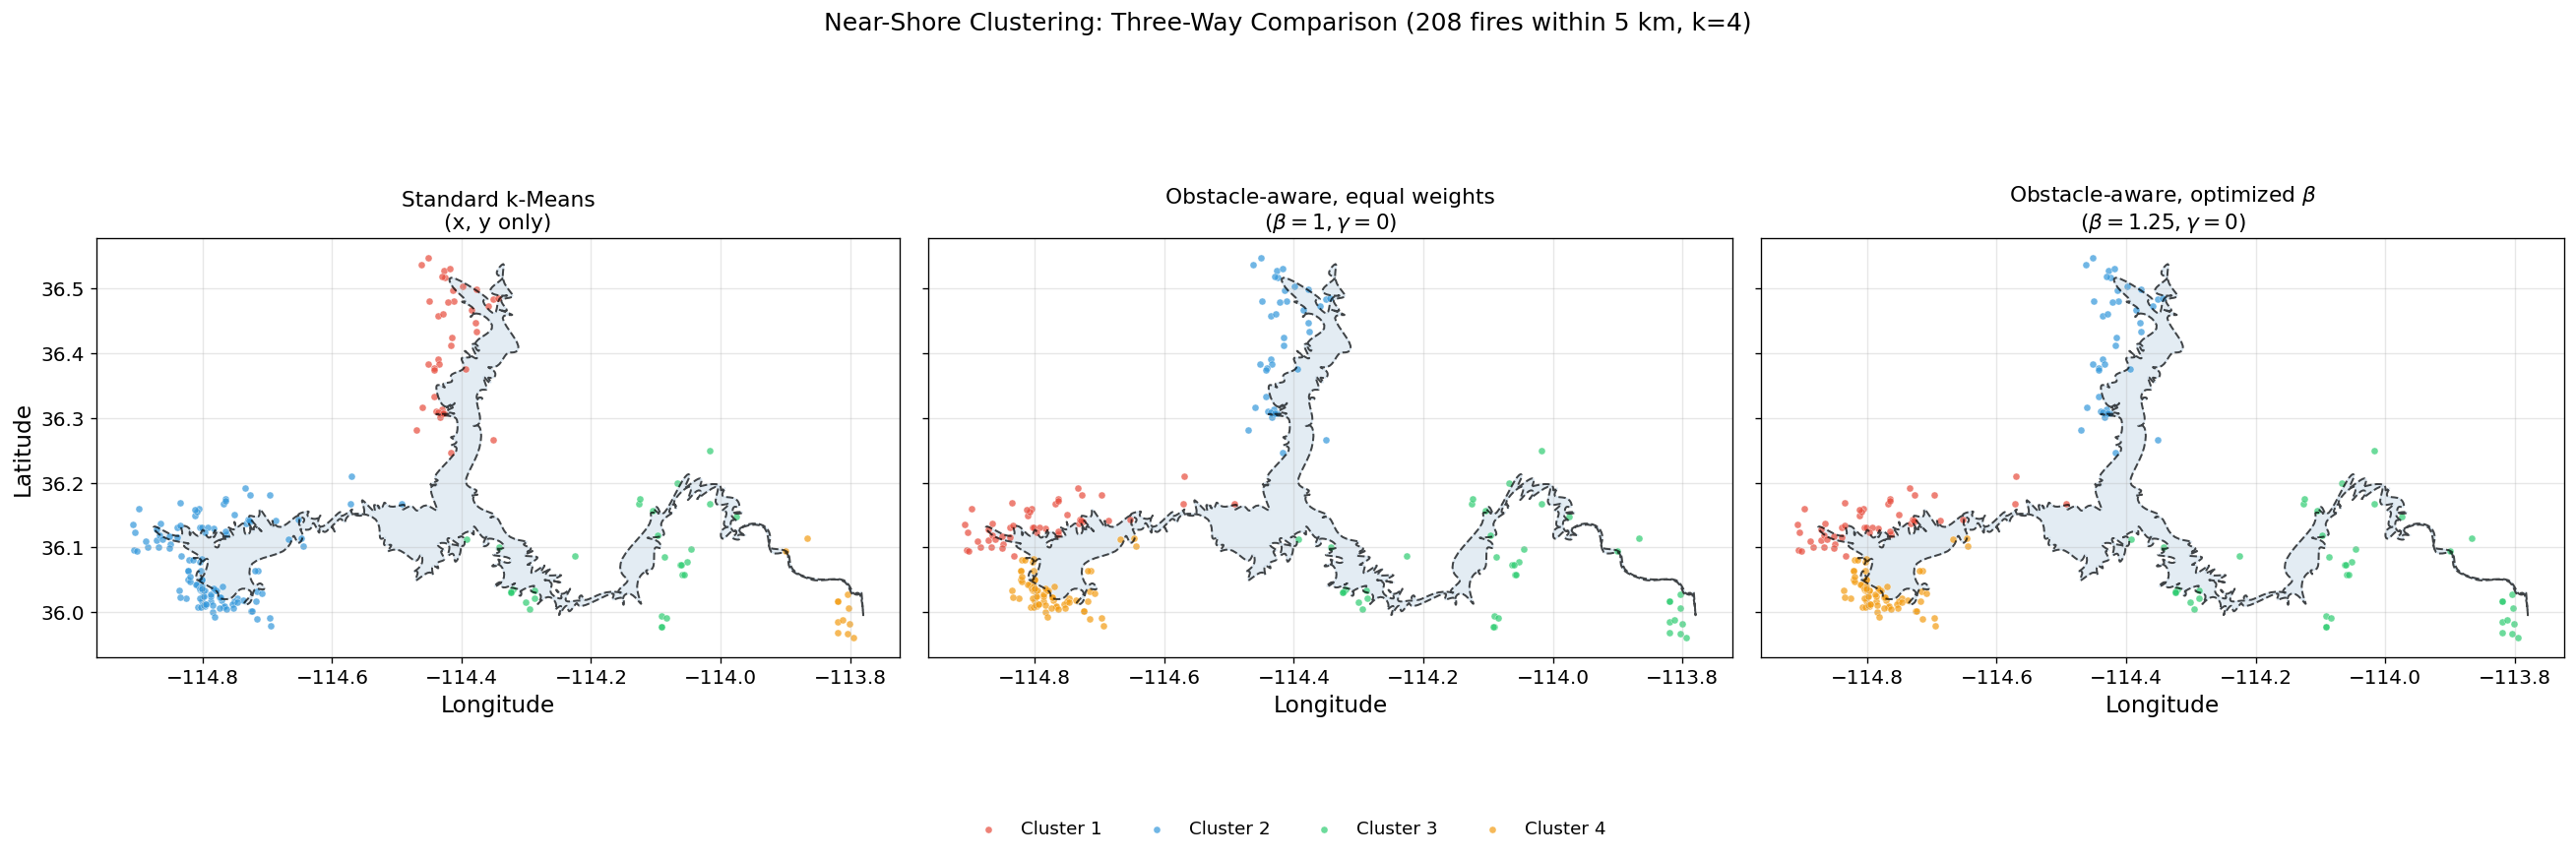

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharex=True, sharey=True)

for ax, labels, title in [
    (axes[0], labels_std_near, 'Standard k-Means\n(x, y only)'),
    (axes[1], labels_eq_near,
     rf'Obstacle-aware, equal weights' + '\n' + rf'($\beta = 1, \gamma = 0$)'),
    (axes[2], labels_opt_near,
     rf'Obstacle-aware, optimized $\beta$' + '\n' +
     rf'($\beta = {opt_beta_near:.2f}, \gamma = 0$)'),
]:
    ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
            linewidth=1.2, alpha=0.7)
    ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.15, color='steelblue')

    for i in range(k):
        mask = labels == i
        ax.scatter(fires_near['LONGITUDE'].values[mask],
                   fires_near['LATITUDE'].values[mask],
                   c=CLUSTER_COLORS[i], s=18, alpha=0.7,
                   label=f'Cluster {i+1}', edgecolors='white', linewidth=0.3)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Longitude')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Latitude')

handles, leg_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, leg_labels, loc='lower center', ncol=k,
           bbox_to_anchor=(0.5, -0.02), frameon=False, fontsize=11)

fig.suptitle(
    f'Near-Shore Clustering: Three-Way Comparison '
    f'({n_near} fires within {threshold_km} km, k={k})',
    fontsize=15, y=1.00
)
plt.tight_layout()
plt.show()

### 11.5 Comparison Statistics

In [48]:
span_pct_eq_near = (
    100 * (np.mean(spans_std_near) - np.mean(spans_eq_near))
    / np.mean(spans_std_near)
)
span_pct_opt_near = (
    100 * (np.mean(spans_std_near) - np.mean(spans_opt_near))
    / np.mean(spans_std_near)
)

print(f'Lake Mead near-shore clustering comparison '
      f'({n_near} fires within {threshold_km} km of lake):')
print()
print(f'  Standard k-Means on scaled XY:')
print(f'    span = {np.mean(spans_std_near):.4f}, σ_a = {sigma_std_near:.4f}')
print()
print(f'  Obstacle-aware, equal weights (β = 1, γ = 0):')
print(f'    span = {np.mean(spans_eq_near):.4f}, σ_a = {sigma_eq_near:.4f}')
print(f'    vs standard: span {span_pct_eq_near:+.1f}%')
print()
print(f'  Obstacle-aware, optimized β = {opt_beta_near:.4f} (γ = 0):')
print(f'    span = {np.mean(spans_opt_near):.4f}, σ_a = {sigma_opt_near:.4f}')
print(f'    vs standard: span {span_pct_opt_near:+.1f}%')
print()
print('Compare to full-dataset results from Section 9:')
print(f'  OA equal weights:    span improvement vs standard: '
      f'{100 * (np.mean(spans_std) - np.mean(spans_eq)) / np.mean(spans_std):+.1f}%')
print(f'  OA optimized β:     span improvement vs standard: '
      f'{100 * (np.mean(spans_std) - np.mean(spans_opt)) / np.mean(spans_std):+.1f}%')

Lake Mead near-shore clustering comparison (208 fires within 5 km of lake):

  Standard k-Means on scaled XY:
    span = 0.2110, σ_a = 0.3333

  Obstacle-aware, equal weights (β = 1, γ = 0):
    span = 0.2007, σ_a = 0.4167
    vs standard: span +4.9%

  Obstacle-aware, optimized β = 1.2500 (γ = 0):
    span = 0.2007, σ_a = 0.4167
    vs standard: span +4.9%

Compare to full-dataset results from Section 9:
  OA equal weights:    span improvement vs standard: +0.0%
  OA optimized β:     span improvement vs standard: +9.6%


### 11.6 Saving the Near-Shore Subset

In [ ]:
# Add cluster labels to the near-shore subset
fires_near['cluster_std'] = labels_std_near
fires_near['cluster_oa_equal'] = labels_eq_near
fires_near['cluster_oa_opt'] = labels_opt_near

near_shore_path = processed_dir / 'mead_fires_nearshore.csv'
fires_near.to_csv(near_shore_path, index=False)
print(f'Saved {len(fires_near)} near-shore fires (with all cluster labels) to:')
print(f'  {near_shore_path}')

Lake Mead near-shore clustering comparison (208 fires within 5 km of lake):

  Standard k-Means on XY (no s):
    span = 0.2233, σ_a = 0.4167

  Obstacle-aware, equal weights (β = 1, γ = 0):
    span = 0.2007, σ_a = 0.4167
    vs standard: span +10.1%

  Obstacle-aware, optimized β = 1.9000 (γ = 0):
    span = 0.2005, σ_a = 0.3333
    vs standard: span +10.2%

Compare to full-dataset results from Section 9:
  OA equal weights:    span improvement vs standard: +0.5%
  OA optimized β:     span improvement vs standard: +6.3%


## 12. Decision Point

The near-shore subset is the cleaner test of whether obstacle-aware clustering actually works for this data. Compare the span improvement here against the full-dataset results from Section 9.

**If the near-shore subset shows substantially larger span improvement than the full dataset**, we have a clear case study. The story is:

- $s$ has modest effect on the full dataset because most fires are too far from the lake for the obstacle to matter
- $s$ has strong effect on the near-shore subset where the obstacle physically constrains positions
- The Tahoe analysis is the contrast: even when restricted to near-shore fires, Tahoe's geometry doesn't create clustering ambiguity, so $s$ doesn't help there

Now that the ObstacleKMeans calls are using 3-column feature matrices (matching Notebook 03's Tier 1), the Mead and Tahoe comparisons are methodologically consistent.